In [1]:
!pip install lightgbm`

/bin/bash: -c: line 1: unexpected EOF while looking for matching ``'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [2]:
!pip install optuna

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


In [4]:
[f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]

['NanumGothic',
 'NanumMyeongjo',
 'NanumBarunGothic',
 'NanumBarunGothic',
 'NanumGothic',
 'NanumSquareRound',
 'NanumGothicCoding',
 'NanumSquare',
 'NanumMyeongjo',
 'NanumGothicCoding',
 'NanumSquare',
 'NanumSquareRound']

### 한글 폰트 설치

In [5]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [6]:
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [7]:
# 데이터 불러오기
df = pd.read_csv("final_dataset_230101-241231.csv")

print(df.head())
print(df.columns)

           날짜              역명   호선  승차인원  시간  하차인원  요일  월  공휴일여부   기온  강수량  \
0  2023-01-01              시청  2호선    43   5    36   6  1      1  0.8  0.0   
1  2023-01-01           을지로입구  2호선   108   5   114   6  1      1  0.8  0.0   
2  2023-01-01           을지로3가  2호선    52   5    55   6  1      1  0.8  0.0   
3  2023-01-01           을지로4가  2호선    21   5    37   6  1      1  0.8  0.0   
4  2023-01-01  동대문역사문화공원(DDP)  2호선    63   5    49   6  1      1  0.8  0.0   

    적설  
0  0.0  
1  0.0  
2  0.0  
3  0.0  
4  0.0  
Index(['날짜', '역명', '호선', '승차인원', '시간', '하차인원', '요일', '월', '공휴일여부', '기온', '강수량',
       '적설'],
      dtype='object')


# 결측치 확인

In [8]:
print(df.isnull().sum())

날짜       0
역명       0
호선       0
승차인원     0
시간       0
하차인원     0
요일       0
월        0
공휴일여부    0
기온       0
강수량      0
적설       0
dtype: int64


# 날짜처리 함수

In [9]:
if "날짜" in df.columns:
    df["날짜"] = pd.to_datetime(df["날짜"])

    df["year"] = df["날짜"].dt.year
    df["month"] = df["날짜"].dt.month
    df["day"] = df["날짜"].dt.day
    df["weekday"] = df["날짜"].dt.weekday

# 원본 날짜 컬럼 제거
df = df.drop(columns=["날짜"])

In [10]:
# 'month' 컬럼을 삭제하는 코드
df = df.drop('month', axis=1)

# 문자열 컬럼을 카테고리로 변경

In [11]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype("category")

# 승하차인원 예측 모델을 공통으로 학습하기 위한 함수
### Light GBM + Optuna 사용

In [12]:
def train_model(df, target_col):

    # 다른 타겟 제거
    drop_cols = []

    if target_col == "승차인원":
        drop_cols = ["하차인원"]

    elif target_col == "하차인원":
        drop_cols = ["승차인원"]

    # feature / target 생성

    X = df.drop(columns=drop_cols + [target_col])

    # datetime 컬럼 제거
    datetime_cols = X.select_dtypes(
        include=['datetime64']
    ).columns

    X = X.drop(columns=datetime_cols)

    y = df[target_col]

    # train / test split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Optuna 목적 함수

    def objective(trial):

        params = {

            "objective": "regression",
            "metric": "mae",
            "boosting_type": "gbdt",

            "n_estimators": trial.suggest_int(
                "n_estimators",
                100,
                1250
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.1,
                log=True
            ),

            "num_leaves": trial.suggest_int(
                "num_leaves",
                20,
                200
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                15
            ),

            "min_child_samples": trial.suggest_int(
                "min_child_samples",
                5,
                100
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.5,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.5,
                1.0
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-3,
                10.0,
                log=True
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-3,
                10.0,
                log=True
            ),

            "random_state": 42,
            "verbosity": -1
        }

        model = lgb.LGBMRegressor(**params)

        model.fit(
            X_train,
            y_train,

            eval_set=[(X_test, y_test)],

            eval_metric="mae",

            callbacks=[
                lgb.early_stopping(100),
                lgb.log_evaluation(0)
            ]
        )

        pred = model.predict(X_test)

        mae = mean_absolute_error(
            y_test,
            pred
        )

        return mae

    # Optuna 실행

    study = optuna.create_study(
        direction="minimize"
    )

    study.optimize(
        objective,
        n_trials=30
    )

    print("\n최적 파라미터")
    print(study.best_params)

    # 최종 모델

    best_model = lgb.LGBMRegressor(
        **study.best_params,
        objective="regression",
        random_state=42
    )

    best_model.fit(
        X_train,
        y_train
    )

    # 예측

    pred = best_model.predict(X_test)

    # 평가

    mae = mean_absolute_error(
        y_test,
        pred
    )

    mse = mean_squared_error(
        y_test,
        pred
    )

    rmse = np.sqrt(mse)

    print("\n====================")
    print(f"{target_col} 결과")
    print("====================")

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)


    # return


    return (
        best_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

# 승하차 모델 결과값 출력

In [13]:
ride_model = train_model(
    df,
    "승차인원"
)

[I 2026-06-04 05:44:34,398] A new study created in memory with name: no-name-6c2a86c3-95db-47b4-ac65-520e85cee980


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[646]	valid_0's l1: 188.331


[I 2026-06-04 05:44:52,788] Trial 0 finished with value: 188.3311433228337 and parameters: {'n_estimators': 646, 'learning_rate': 0.01184494108918776, 'num_leaves': 73, 'max_depth': 13, 'min_child_samples': 63, 'subsample': 0.7478939756466016, 'colsample_bytree': 0.6633812608695153, 'reg_alpha': 0.20938111152071495, 'reg_lambda': 0.0417162812811226}. Best is trial 0 with value: 188.3311433228337.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[134]	valid_0's l1: 166.442


[I 2026-06-04 05:44:56,459] Trial 1 finished with value: 166.4423208190398 and parameters: {'n_estimators': 134, 'learning_rate': 0.03009018626902736, 'num_leaves': 78, 'max_depth': 10, 'min_child_samples': 67, 'subsample': 0.949305625946619, 'colsample_bytree': 0.9834920957104151, 'reg_alpha': 0.5763812437238893, 'reg_lambda': 0.021389062084758704}. Best is trial 1 with value: 166.4423208190398.


...

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1171]	valid_0's l1: 69.0014


[I 2026-06-04 05:56:09,466] Trial 28 finished with value: 69.00138844172861 and parameters: {'n_estimators': 1171, 'learning_rate': 0.07479610501468968, 'num_leaves': 139, 'max_depth': 12, 'min_child_samples': 88, 'subsample': 0.9974060366941427, 'colsample_bytree': 0.9994329626025131, 'reg_alpha': 0.0026837126295503988, 'reg_lambda': 0.44654306895311424}. Best is trial 25 with value: 67.12315556840211.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1155]	valid_0's l1: 74.748


[I 2026-06-04 05:56:33,869] Trial 29 finished with value: 74.74801042090895 and parameters: {'n_estimators': 1155, 'learning_rate': 0.049976382199782426, 'num_leaves': 122, 'max_depth': 14, 'min_child_samples': 74, 'subsample': 0.9273251061785012, 'colsample_bytree': 0.9179692343771992, 'reg_alpha': 0.001694548805916707, 'reg_lambda': 0.06989514781439934}. Best is trial 25 with value: 67.12315556840211.



최적 파라미터
{'n_estimators': 1236, 'learning_rate': 0.06698421313369297, 'num_leaves': 175, 'max_depth': 14, 'min_child_samples': 100, 'subsample': 0.9972438163299439, 'colsample_bytree': 0.957920537017446, 'reg_alpha': 0.0027236201523490895, 'reg_lambda': 0.7806030813898681}

승차인원 결과
MAE : 67.12315556840313
MSE : 33781.491125714805
RMSE : 183.7974187134161


In [14]:
# 하차 모델
off_model = train_model(
    df,
    "하차인원"
)

[I 2026-06-04 05:57:00,296] A new study created in memory with name: no-name-a70ecfc6-e4a5-45f5-a1ba-92a4a84744fe


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[854]	valid_0's l1: 137.239


[I 2026-06-04 05:57:20,174] Trial 0 finished with value: 137.2393653509718 and parameters: {'n_estimators': 854, 'learning_rate': 0.026477751150441722, 'num_leaves': 52, 'max_depth': 8, 'min_child_samples': 20, 'subsample': 0.6656680171713367, 'colsample_bytree': 0.6864332439913068, 'reg_alpha': 0.019742395817743116, 'reg_lambda': 0.7253707685825993}. Best is trial 0 with value: 137.2393653509718.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1005]	valid_0's l1: 105.439


[I 2026-06-04 05:57:57,000] Trial 1 finished with value: 105.43868843940936 and parameters: {'n_estimators': 1005, 'learning_rate': 0.015138482052076397, 'num_leaves': 176, 'max_depth': 13, 'min_child_samples': 85, 'subsample': 0.7578829386919695, 'colsample_bytree': 0.6837374330411855, 'reg_alpha': 0.3536963823671678, 'reg_lambda': 0.5345698486207026}. Best is trial 1 with value: 105.43868843940936.


...

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1067]	valid_0's l1: 73.9075


[I 2026-06-04 06:07:10,579] Trial 28 finished with value: 73.90750085784327 and parameters: {'n_estimators': 1067, 'learning_rate': 0.0736938424465821, 'num_leaves': 181, 'max_depth': 11, 'min_child_samples': 46, 'subsample': 0.6323957675604299, 'colsample_bytree': 0.8749601799947978, 'reg_alpha': 0.013430336448987043, 'reg_lambda': 0.01203137300476332}. Best is trial 15 with value: 69.47078858669168.


Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[914]	valid_0's l1: 79.7389


[I 2026-06-04 06:07:34,725] Trial 29 finished with value: 79.73889802750459 and parameters: {'n_estimators': 914, 'learning_rate': 0.036021811680333644, 'num_leaves': 189, 'max_depth': 13, 'min_child_samples': 21, 'subsample': 0.6891273338162257, 'colsample_bytree': 0.9113707762562293, 'reg_alpha': 0.007445684403119764, 'reg_lambda': 0.005028735456640074}. Best is trial 15 with value: 69.47078858669168.



최적 파라미터
{'n_estimators': 1248, 'learning_rate': 0.06495729554566386, 'num_leaves': 198, 'max_depth': 15, 'min_child_samples': 29, 'subsample': 0.5989757978055062, 'colsample_bytree': 0.988449710207921, 'reg_alpha': 0.1632872444486758, 'reg_lambda': 0.1005962027417769}

하차인원 결과
MAE : 69.47078858669168
MSE : 22664.526429860052
RMSE : 150.5474225281192


# 오차율이 어떻게 줄어가는지 나타내는 그래프

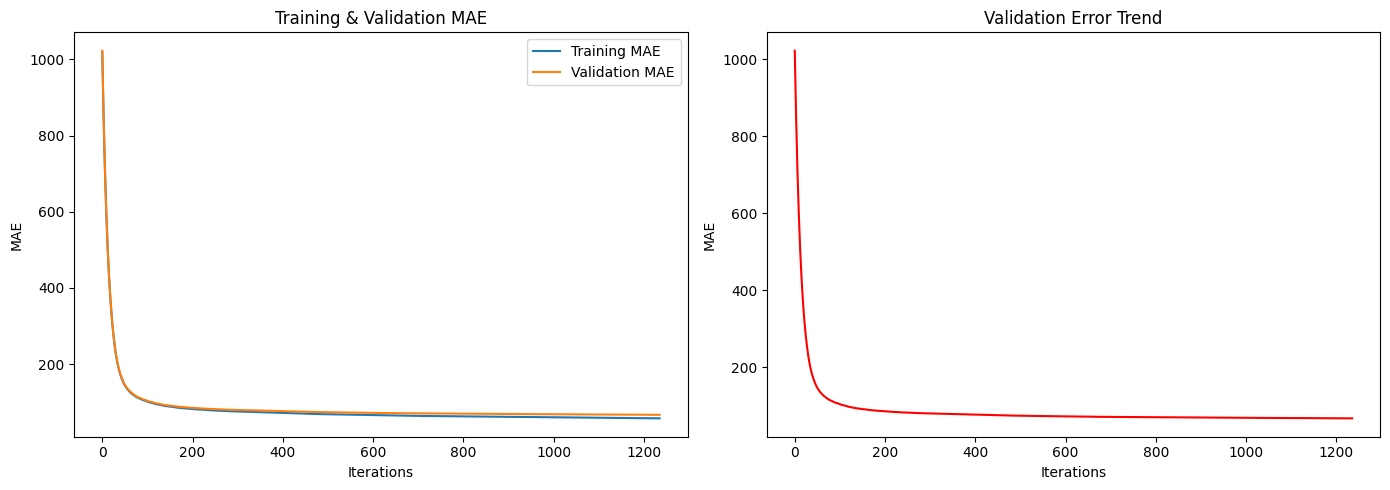

In [15]:
# ride_model에서 값 꺼내기
best_model = ride_model[0]

X_train = ride_model[1]
X_test = ride_model[2]

y_train = ride_model[3]
y_test = ride_model[4]

# 결과 저장
evals_result = {}

# 다시 학습 (그래프 기록용)
best_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],

    eval_metric="l1",

    callbacks=[
        lgb.record_evaluation(evals_result)
    ]
)

# 데이터 가져오기
train_mae = evals_result['training']['l1']
valid_mae = evals_result['valid_1']['l1']

# =========================
# 그래프
# =========================

plt.figure(figsize=(14,5))

# 왼쪽 그래프
plt.subplot(1,2,1)

plt.plot(
    train_mae,
    label='Training MAE'
)

plt.plot(
    valid_mae,
    label='Validation MAE'
)

plt.title('Training & Validation MAE')

plt.xlabel('Iterations')

plt.ylabel('MAE')

plt.legend()

# 오른쪽 그래프
plt.subplot(1,2,2)

plt.plot(
    valid_mae,
    color='red'
)

plt.title('Validation Error Trend')

plt.xlabel('Iterations')

plt.ylabel('MAE')

plt.tight_layout()

plt.show()

# 실제값 vs 예측값 그래프

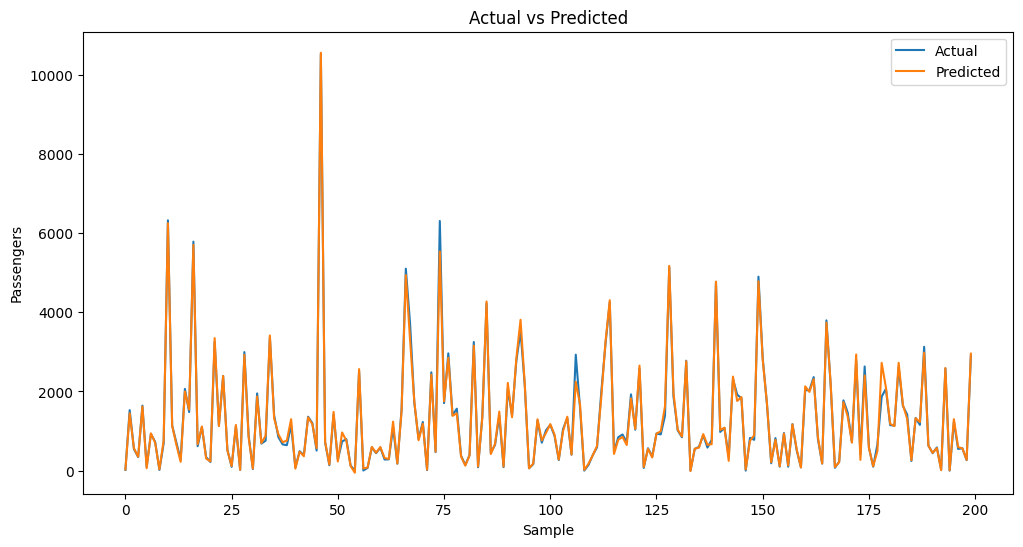

In [16]:
pred = best_model.predict(X_test)

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    pred[:200],
    label="Predicted"
)

plt.title("Actual vs Predicted")

plt.xlabel("Sample")

plt.ylabel("Passengers")

plt.legend()

plt.show()

# 어떤 변수가 승차량에 가장 큰 영향을 줬는지

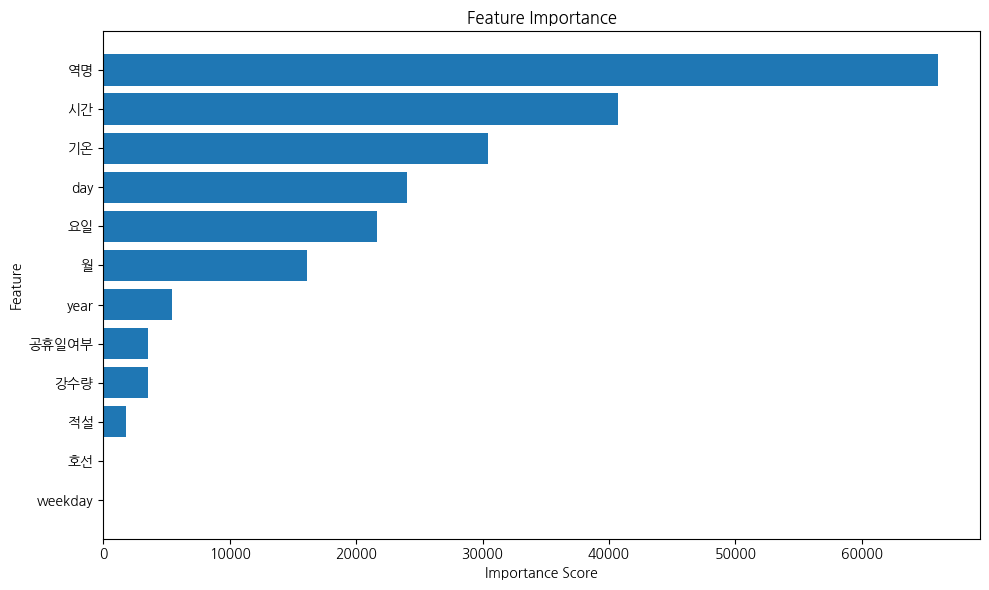

In [17]:
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 모델 가져오기
best_model = ride_model[0]

# feature 이름 가져오기
X_train = ride_model[1]

# 중요도 데이터 생성
importance_df = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

# 중요도 높은 순 정렬
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# 상위 15개만 보기
top_n = 15

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:top_n][::-1],
    importance_df["Importance"][:top_n][::-1]
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print("Train MAE:", train_mae)
print("Test MAE :", test_mae)

Train MAE: 57.83400981183134
Test MAE : 67.12315556840313


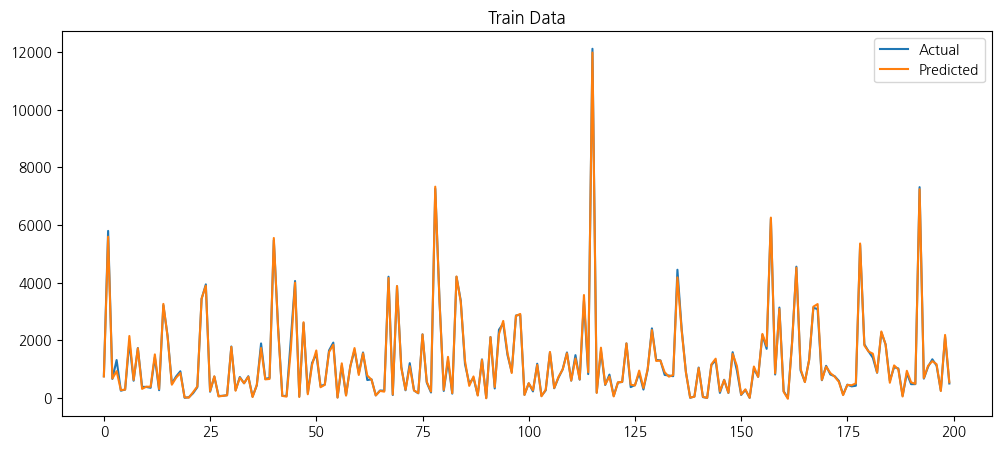

In [19]:
train_pred = best_model.predict(X_train)

plt.figure(figsize=(12,5))

plt.plot(y_train.values[:200], label="Actual")
plt.plot(train_pred[:200], label="Predicted")

plt.title("Train Data")
plt.legend()
plt.show()

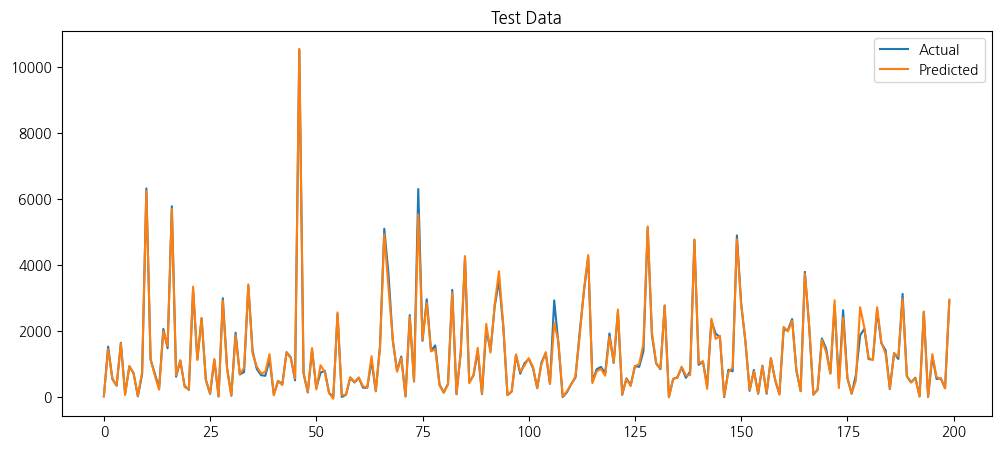

In [20]:
test_pred = best_model.predict(X_test)

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(test_pred[:200], label="Predicted")

plt.title("Test Data")
plt.legend()
plt.show()